In [1]:
from learn_to_infer import Worker
from task import SwitchingBandit
import pandas as pd
import torch
import numpy as np

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [2]:
np.random.exponential(1./10)

0.26836146612548767

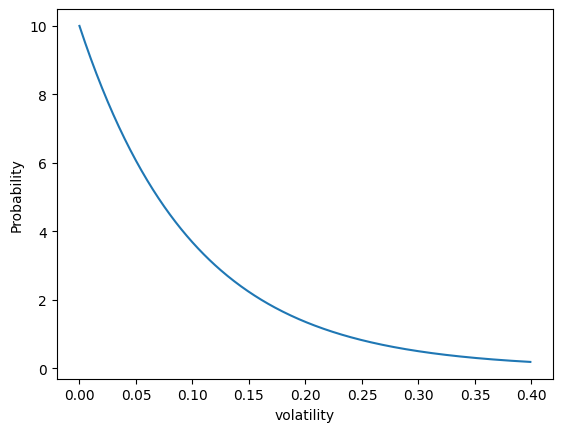

In [3]:
x = np.arange(0, 0.4, 0.001)
lambda_param = 10  # Can be adjusted to change the rate parameter

plt.plot(x, lambda_param * np.exp(-lambda_param * x))
plt.ylabel('Probability')
plt.xlabel('volatility')
plt.savefig('figures/bandit_volatility_distribution.pdf')
plt.show()


In [4]:
def false_positive_rate(llrmax=None, return_stimulus_range=True):
    if llrmax is None:
        llrmax = 0.8 + np.random.rand() * (7 - 0.8)
    nlevel = 50      # Number of discrete stimulus levels
    # Generate stimulus value distribution
    level_list = np.arange(-nlevel, nlevel+1)/nlevel
    llr_list = level_list * llrmax
    p_gen = 1/(1 + np.exp(-llr_list))
    p_gen = p_gen/p_gen.sum()
    stimulus_range = np.round(np.arange(-1.0, 1.02, 0.02), 2)
    if return_stimulus_range:
        return stimulus_range, p_gen
    else:
        return p_gen


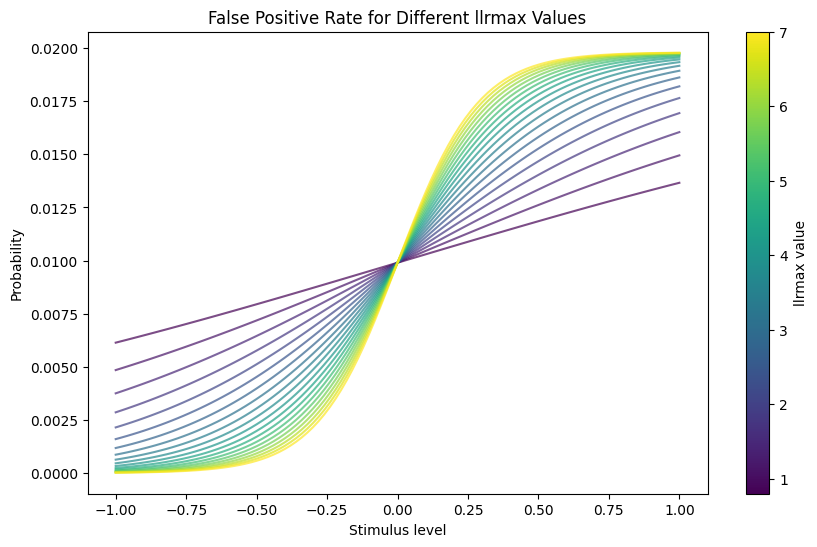

In [5]:
# Create a range of llrmax values from 0.8 to 7
llrmax_values = np.linspace(0.8, 7, 20)

# Create color map
colors = plt.cm.viridis(np.linspace(0, 1, len(llrmax_values)))

fig, ax = plt.subplots(figsize=(10, 6))
for i, llrmax in enumerate(llrmax_values):
    s, p = false_positive_rate(llrmax=llrmax)
    ax.plot(s, p, color=colors[i], alpha=0.7, label=f'llrmax={llrmax:.1f}')

ax.set_ylabel('Probability')
ax.set_xlabel('Stimulus level')
plt.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0.8, 7), cmap='viridis'), 
            ax=ax, label='llrmax value')
ax.set_title('False Positive Rate for Different llrmax Values')
plt.savefig('figures/bandit_false_positive_rate.pdf')
plt.show()

In [44]:
s, p = false_positive_rate(llrmax=1.7954)
p[s <= 0].sum()

0.30389177711184084

In [50]:
s, p = false_positive_rate(llrmax=0.8)
p[s <= 0].sum()

0.4065934266033165

In [54]:
s, p = false_positive_rate(llrmax=7)
p[s <= 0].sum()

0.10292876967017284